# PMO Benchmark Analysis

This notebook analyzes the results from the Practical Molecular Optimization (PMO) benchmark.

## Metrics

From the paper:
> To consider the optimization ability and sample efficiency simultaneously, we report the area under the curve (AUC) of top-K average property value versus the number of oracle calls (AUC top-K) as the primary metric to measure the performance. Unlike using top-K average property, AUC rewards methods that reach high values with fewer oracle calls. We use K = 10 in this paper as it is useful to identify a small number of distinct molecular candidates to progress to later stages of development. We limit the number of oracle calls to 10000, though we expect methods to optimize well within hundreds of calls when using experimental evaluations. The reported values of AUCs are min-max scaled to [0, 1].

In [1]:
import re
import heapq
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Define paths
RESULTS_DIR = Path("../data/results/pmo_baseline")


# Define model mappings from filename to display name (all 25 models in the data)
MODEL_MAPPING = {
    # Top performers
    'reinvent': 'REINVENT',
    'reinvent_selfies': 'REINVENT SELFIES',
    'graph_ga': 'Graph GA',
    'gp_bo': 'GP BO',
    'stoned': 'STONED',
    # LSTM / GA variants
    'smiles_lstm_hc': 'SMILES LSTM HC',
    'selfies_lstm_hc': 'SELFIES LSTM HC',
    'smiles_ga': 'SMILES GA',
    'selfies_ga': 'SELFIES GA',
    # VAE-based
    'smiles_vae_bo': 'SMILES VAE BO',
    'selfies_vae_bo': 'SELFIES VAE BO',
    'jt_vae_bo': 'JT-VAE BO',
    # Synthesis-aware
    'synnet': 'SynNet',
    'dog_gen': 'DoG-Gen',
    'dog_ae': 'DoG-AE',
    # GFlowNet variants
    'gflownet': 'GFlowNet',
    'gflownet_al': 'GFlowNet-AL',
    # Others
    'dst': 'DST',
    'mars': 'MARS',
    'mimosa': 'MIMOSA',
    'pasithea': 'Pasithea',
    'mol_pal': 'MolPAL',
    'graph_mcts': 'Graph MCTS',
    'moldqn': 'MolDQN',
    'screening': 'Screening',
}

# List of all 23 PMO benchmark tasks
TASKS = [
    'albuterol_similarity',
    'amlodipine_mpo',
    'celecoxib_rediscovery',
    'deco_hop',
    'drd2',
    'fexofenadine_mpo',
    'gsk3b',
    'isomers_c7h8n2o2',
    'isomers_c9h10n2o2pf2cl',
    'jnk3',
    'median1',
    'median2',
    'mestranol_similarity',
    'osimertinib_mpo',
    'perindopril_mpo',
    'qed',
    'ranolazine_mpo',
    'scaffold_hop',
    'sitagliptin_mpo',
    'thiothixene_rediscovery',
    'troglitazone_rediscovery',
    'valsartan_smarts',
    'zaleplon_mpo',
]

In [3]:
def load_yaml_results_fast(filepath):
    """Load results from a YAML file using fast custom parsing.
    
    The YAML file format is very simple:
    SMILES:
    - score
    - oracle_call_number
    
    This custom parser is 10-20x faster than yaml.safe_load() for this format.
    
    Returns a list of (score, oracle_call) tuples sorted by oracle_call.
    """
    results = []
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    i = 0
    n = len(lines)
    while i < n:
        line = lines[i]
        # Skip empty lines
        if not line.strip():
            i += 1
            continue
        # Check if this is a SMILES line (doesn't start with -)
        if not line.startswith('-'):
            # Next two lines should be - score and - oracle_call
            if i + 2 < n:
                score_line = lines[i + 1].strip()
                oracle_line = lines[i + 2].strip()
                if score_line.startswith('- ') and oracle_line.startswith('- '):
                    try:
                        score = float(score_line[2:])
                        oracle_call = int(oracle_line[2:])
                        results.append((score, oracle_call))
                    except (ValueError, IndexError):
                        pass
                    i += 3
                    continue
        i += 1
    
    # Sort by oracle call number
    results.sort(key=lambda x: x[1])
    return results


In [4]:
def compute_auc_top_k(results, k=10, max_oracle_calls=10000):
    """Compute the AUC of top-K average property value vs oracle calls.
    
    Uses a min-heap to efficiently track top-k scores in O(n log k) instead of O(n² log n).
    
    Args:
        results: List of (score, oracle_call) tuples sorted by oracle_call
        k: Number of top molecules to consider (default 10)
        max_oracle_calls: Maximum number of oracle calls (default 10000)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    if not results:
        return 0.0
    
    # Use a min-heap of size k to track top-k scores efficiently
    # This gives O(n log k) instead of O(n² log n)
    top_k_heap = []  # min-heap: smallest of top-k is at index 0
    heap_sum = 0.0   # running sum of elements in heap
    top_k_avg_at_call = {}  # oracle_call -> top-k average
    
    for score, oracle_call in results:
        if oracle_call > max_oracle_calls:
            break
        
        if len(top_k_heap) < k:
            # Heap not full yet, just add
            heapq.heappush(top_k_heap, score)
            heap_sum += score
        elif score > top_k_heap[0]:
            # New score is larger than smallest in top-k, replace it
            old_min = heapq.heapreplace(top_k_heap, score)
            heap_sum += score - old_min
        # else: score <= min of top-k, ignore it
        
        top_k_avg_at_call[oracle_call] = heap_sum / len(top_k_heap)
    
    if not top_k_avg_at_call:
        return 0.0
    
    # Compute AUC using trapezoidal rule
    oracle_calls = sorted(top_k_avg_at_call.keys())
    
    # Compute AUC as sum of rectangles
    auc = 0.0
    prev_call = 0
    prev_avg = 0.0  # Before any calls, the average is 0
    
    for call in oracle_calls:
        # Area of rectangle from prev_call to call with height prev_avg
        auc += prev_avg * (call - prev_call)
        prev_call = call
        prev_avg = top_k_avg_at_call[call]
    
    # Add final rectangle from last call to max_oracle_calls
    auc += prev_avg * (max_oracle_calls - prev_call)
    
    # Normalize by max possible AUC (max_oracle_calls * 1.0)
    normalized_auc = auc / max_oracle_calls
    
    return normalized_auc

In [5]:
def parse_filename(filename):
    """Parse model name and task from filename.
    
    Filename format: results_{model}_{task}_{run}.yaml
    
    Returns: (model, task, run) or (None, None, None) if parsing fails
    """
    # Remove 'results_' prefix and '.yaml' suffix
    name = filename.replace('results_', '').replace('.yaml', '')
    
    # Extract run number (last underscore followed by digit(s))
    match = re.match(r'(.+)_(\d+)$', name)
    if not match:
        return None, None, None
    
    model_task = match.group(1)
    run = int(match.group(2))
    
    # Try to match each known model prefix
    for model_key in sorted(MODEL_MAPPING.keys(), key=len, reverse=True):
        if model_task.startswith(model_key + '_'):
            task = model_task[len(model_key) + 1:]
            if task in TASKS:
                return model_key, task, run
    
    return None, None, None

In [6]:
# Load results - with parquet caching for fast subsequent loads
import time

CACHE_FILE = RESULTS_DIR / "auc_cache.parquet"
FORCE_RELOAD = False  # Set to True to recompute from YAML files

def load_from_yaml_files():
    """Load and compute AUC from YAML files (slow, ~30s)."""
    start_time = time.time()
    
    # Helper function for parallel processing
    def process_file(filepath_info):
        filepath, model, task = filepath_info
        results = load_yaml_results_fast(filepath)
        auc = compute_auc_top_k(results)
        return model, task, auc, filepath.name

    # Collect all file paths to process
    files_to_process = []
    for model in MODEL_MAPPING:
        for task in TASKS:
            pattern = f"results_{model}_{task}_*.yaml"
            for filepath in RESULTS_DIR.glob(pattern):
                files_to_process.append((filepath, model, task))

    print(f"Found {len(files_to_process)} YAML files to process")
    
    # Process files in parallel
    rows = []
    n_workers = 8
    print(f"Processing with {n_workers} parallel workers...")
    
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(process_file, fp_info) for fp_info in files_to_process]
        for i, future in enumerate(as_completed(futures)):
            model, task, auc, filename = future.result()
            rows.append({"model": model, "task": task, "auc": auc, "filename": filename})
            if (i + 1) % 200 == 0:
                print(f"  Processed {i + 1}/{len(files_to_process)} files...")
    
    elapsed = time.time() - start_time
    print(f"Processed {len(rows)} files in {elapsed:.1f}s")
    return pd.DataFrame(rows)


def load_results():
    """Load results from cache if available, otherwise from YAML files."""
    if CACHE_FILE.exists() and not FORCE_RELOAD:
        print(f"Loading from cache: {CACHE_FILE}")
        start = time.time()
        df = pd.read_parquet(CACHE_FILE)
        print(f"Loaded {len(df)} results in {time.time() - start:.2f}s")
    else:
        print("Computing AUC from YAML files (this will be cached)...")
        df = load_from_yaml_files()
        # Save cache
        df.to_parquet(CACHE_FILE)
        print(f"Saved cache to {CACHE_FILE}")
    return df


# Load and convert to nested dict structure
results_df = load_results()

all_results = defaultdict(lambda: defaultdict(list))
for _, row in results_df.iterrows():
    all_results[row["model"]][row["task"]].append(row["auc"])

print(f"\nLoaded {len(results_df)} results for {len(all_results)} models")
print(f"Loaded models: {[MODEL_MAPPING[m] for m in all_results.keys()]}")

Loading from cache: ../data/results/pmo_baseline/auc_cache.parquet
Loaded 2875 results in 0.05s

Loaded 2875 results for 25 models
Loaded models: ['REINVENT', 'REINVENT SELFIES', 'Graph GA', 'GP BO', 'STONED', 'SMILES LSTM HC', 'SELFIES LSTM HC', 'SMILES GA', 'SELFIES GA', 'SMILES VAE BO', 'SELFIES VAE BO', 'JT-VAE BO', 'SynNet', 'DoG-Gen', 'DoG-AE', 'GFlowNet', 'GFlowNet-AL', 'DST', 'MARS', 'MIMOSA', 'Pasithea', 'MolPAL', 'Graph MCTS', 'MolDQN', 'Screening']


In [7]:
# Create summary table with mean ± std
def create_summary_table(results_dict, models_order):
    """Create a summary table with mean ± std for each model/task combination."""
    rows = []
    
    for task in TASKS:
        row = {'Task': task}
        for model in models_order:
            if model in results_dict and task in results_dict[model]:
                values = results_dict[model][task]
                mean = np.mean(values)
                std = np.std(values)
                row[MODEL_MAPPING[model]] = f"{mean:.3f}± {std:.3f}"
            else:
                row[MODEL_MAPPING[model]] = "-"
        rows.append(row)
    
    # Add sum row
    sum_row = {'Task': 'Sum'}
    for model in models_order:
        if model in results_dict:
            total = 0
            for task in TASKS:
                if task in results_dict[model]:
                    total += np.mean(results_dict[model][task])
            sum_row[MODEL_MAPPING[model]] = f"{total:.3f}"
        else:
            sum_row[MODEL_MAPPING[model]] = "-"
    rows.append(sum_row)
    
    df = pd.DataFrame(rows)
    return df

In [8]:
# Create combined table with all models and rank them by sum
all_models = list(all_results.keys())

# Calculate sum for each model
model_sums = {}
for model in all_models:
    total = sum(np.mean(all_results[model][task]) for task in TASKS if task in all_results[model])
    model_sums[model] = total

# Sort models by sum (descending)
sorted_models = sorted(all_models, key=lambda m: model_sums[m], reverse=True)

print("\n" + "="*80)
print("COMBINED TABLE (All Models, Ranked by Sum)")
print("="*80 + "\n")

combined_table = create_summary_table(all_results, sorted_models)

# Add rank row
rank_row = {'Task': 'Rank'}
for i, model in enumerate(sorted_models, 1):
    rank_row[MODEL_MAPPING[model]] = str(i)
combined_table = pd.concat([combined_table, pd.DataFrame([rank_row])], ignore_index=True)

display(combined_table)


COMBINED TABLE (All Models, Ranked by Sum)



,Task,REINVENT,Graph GA,REINVENT SELFIES,GP BO,STONED,SMILES LSTM HC,SMILES GA,SynNet,DoG-Gen,MARS,DST,MIMOSA,MolPAL,SELFIES LSTM HC,DoG-AE,GFlowNet,SELFIES GA,SELFIES VAE BO,Screening,SMILES VAE BO,Pasithea,GFlowNet-AL,JT-VAE BO,Graph MCTS,MolDQN
0,albuterol_similarity,0.884± 0.006,0.840± 0.016,0.828± 0.030,0.900± 0.014,0.747± 0.076,0.720± 0.019,0.663± 0.066,0.585± 0.039,0.678± 0.014,0.599± 0.125,0.621± 0.020,0.619± 0.017,0.611± 0.002,0.665± 0.030,0.535± 0.035,0.448± 0.013,0.496± 0.026,0.496± 0.013,0.485± 0.007,0.490± 0.008,0.449± 0.007,0.392± 0.008,0.487± 0.030,0.582± 0.023,0.321± 0.015
1,amlodipine_mpo,0.637± 0.036,0.663± 0.021,0.608± 0.014,0.585± 0.044,0.611± 0.047,0.595± 0.017,0.551± 0.010,0.567± 0.007,0.537± 0.003,0.506± 0.017,0.519± 0.008,0.545± 0.004,0.583± 0.009,0.534± 0.005,0.509± 0.005,0.445± 0.005,0.401± 0.033,0.518± 0.006,0.537± 0.002,0.535± 0.010,0.507± 0.003,0.429± 0.003,0.521± 0.010,0.447± 0.008,0.312± 0.009
2,celecoxib_rediscovery,0.714± 0.067,0.631± 0.098,0.574± 0.044,0.725± 0.053,0.383± 0.041,0.540± 0.019,0.345± 0.027,0.443± 0.027,0.466± 0.009,0.380± 0.060,0.381± 0.007,0.395± 0.010,0.416± 0.002,0.387± 0.009,0.356± 0.012,0.328± 0.005,0.224± 0.026,0.327± 0.008,0.353± 0.005,0.355± 0.003,0.314± 0.008,0.258± 0.004,0.300± 0.009,0.265± 0.013,0.100± 0.006
3,deco_hop,0.669± 0.045,0.622± 0.005,0.634± 0.012,0.632± 0.019,0.614± 0.009,0.830± 0.018,0.614± 0.007,0.616± 0.009,0.803± 0.008,0.593± 0.003,0.611± 0.009,0.622± 0.004,0.646± 0.006,0.593± 0.002,0.763± 0.063,0.586± 0.002,0.553± 0.005,0.582± 0.001,0.593± 0.002,0.593± 0.001,0.582± 0.002,0.586± 0.002,0.588± 0.003,0.557± 0.002,0.549± 0.001
4,drd2,0.946± 0.007,0.964± 0.013,0.943± 0.006,0.924± 0.017,0.914± 0.021,0.919± 0.016,0.908± 0.019,0.969± 0.005,0.949± 0.001,0.891± 0.020,0.821± 0.015,0.800± 0.017,0.783± 0.010,0.729± 0.035,0.944± 0.009,0.591± 0.070,0.382± 0.205,0.569± 0.039,0.545± 0.016,0.555± 0.043,0.256± 0.041,0.469± 0.046,0.507± 0.136,0.300± 0.051,0.025± 0.001
5,fexofenadine_mpo,0.787± 0.006,0.763± 0.012,0.743± 0.003,0.724± 0.005,0.800± 0.016,0.727± 0.004,0.723± 0.016,0.764± 0.015,0.697± 0.004,0.713± 0.006,0.727± 0.005,0.709± 0.012,0.686± 0.000,0.696± 0.005,0.681± 0.018,0.696± 0.007,0.587± 0.008,0.672± 0.004,0.668± 0.005,0.673± 0.004,0.662± 0.015,0.691± 0.003,0.670± 0.010,0.575± 0.009,0.479± 0.012
6,gsk3b,0.866± 0.044,0.789± 0.070,0.780± 0.038,0.851± 0.041,0.670± 0.049,0.840± 0.016,0.630± 0.045,0.790± 0.033,0.832± 0.021,0.553± 0.038,0.669± 0.033,0.555± 0.042,0.556± 0.011,0.424± 0.019,0.602± 0.092,0.645± 0.027,0.343± 0.019,0.351± 0.035,0.438± 0.034,0.386± 0.007,0.281± 0.039,0.584± 0.014,0.351± 0.051,0.282± 0.023,0.242± 0.009
7,isomers_c7h8n2o2,0.852± 0.036,0.862± 0.066,0.849± 0.034,0.680± 0.117,0.900± 0.012,0.485± 0.046,0.914± 0.021,0.456± 0.032,0.465± 0.019,0.729± 0.028,0.548± 0.070,0.565± 0.046,0.484± 0.006,0.587± 0.031,0.239± 0.078,0.367± 0.043,0.854± 0.015,0.325± 0.028,0.169± 0.034,0.161± 0.017,0.674± 0.030,0.241± 0.055,0.103± 0.016,0.531± 0.035,0.431± 0.035
8,isomers_c9h10n2o2pf2cl,0.643± 0.054,0.719± 0.048,0.733± 0.029,0.470± 0.180,0.806± 0.031,0.343± 0.027,0.861± 0.065,0.242± 0.065,0.199± 0.016,0.581± 0.013,0.458± 0.063,0.303± 0.046,0.164± 0.003,0.352± 0.019,0.050± 0.016,0.110± 0.032,0.657± 0.020,0.201± 0.030,0.106± 0.022,0.085± 0.010,0.346± 0.145,0.064± 0.012,0.091± 0.036,0.454± 0.067,0.343± 0.027
9,jnk3,0.784± 0.024,0.554± 0.136,0.631± 0.064,0.565± 0.156,0.524± 0.092,0.661± 0.039,0.317± 0.022,0.631± 0.035,0.596± 0.024,0.489± 0.095,0.544± 0.067,0.361± 0.064,0.339± 0.010,0.207± 0.014,0.470± 0.138,0.422± 0.026,0.220± 0.022,0.209± 0.023,0.239± 0.025,0.242± 0.027,0.155± 0.018,0.359± 0.022,0.223± 0.010,0.111± 0.020,0.111± 0.008


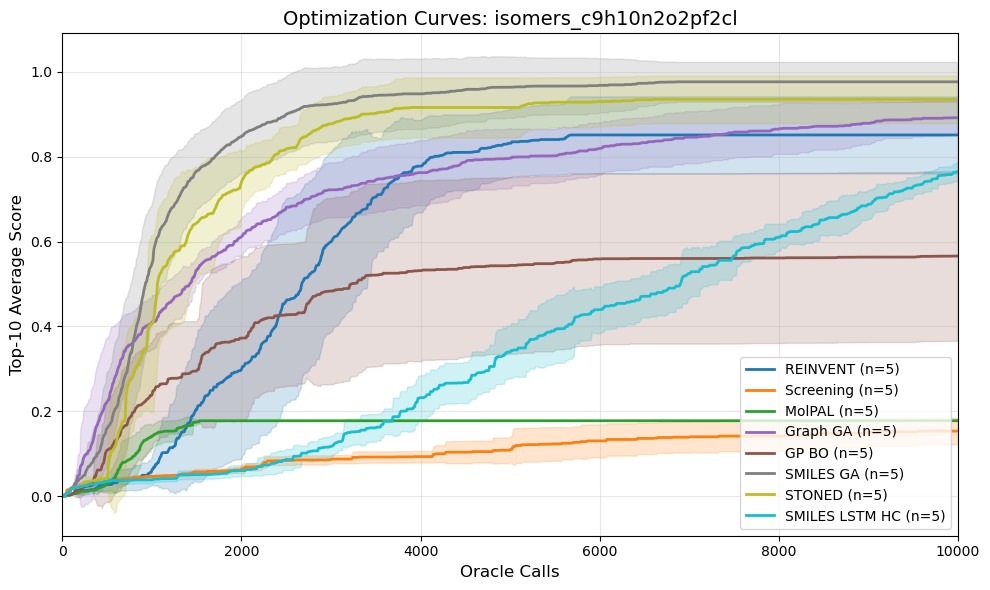

In [9]:
import matplotlib.pyplot as plt

def compute_top_k_curve(results, k=10, max_oracle_calls=10000):
    """Compute top-K average at each oracle call.
    
    Args:
        results: List of (score, oracle_call) tuples sorted by oracle_call
        k: Number of top molecules to consider (default 10)
        max_oracle_calls: Maximum number of oracle calls (default 10000)
    
    Returns:
        Tuple of (oracle_calls, top_k_averages) arrays
    """
    if not results:
        return np.array([]), np.array([])
    
    top_k_heap = []
    heap_sum = 0.0
    oracle_calls = []
    top_k_avgs = []
    
    for score, oracle_call in results:
        if oracle_call > max_oracle_calls:
            break
        
        if len(top_k_heap) < k:
            heapq.heappush(top_k_heap, score)
            heap_sum += score
        elif score > top_k_heap[0]:
            old_min = heapq.heapreplace(top_k_heap, score)
            heap_sum += score - old_min
        
        oracle_calls.append(oracle_call)
        top_k_avgs.append(heap_sum / len(top_k_heap))
    
    return np.array(oracle_calls), np.array(top_k_avgs)


def plot_optimization_curves(task, models_to_plot, results_dir=RESULTS_DIR, max_oracle_calls=10000):
    """Plot optimization curves (top-10 avg vs oracle calls) for specified models.
    
    Args:
        task: Task name (e.g., 'isomers_c9h10n2o2pf2cl')
        models_to_plot: List of model keys to plot
        results_dir: Directory containing result YAML files
        max_oracle_calls: Maximum oracle calls to show
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define a nice color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_to_plot)))
    
    for model_key, color in zip(models_to_plot, colors):
        # Load all runs for this model/task
        pattern = f"results_{model_key}_{task}_*.yaml"
        files = list(results_dir.glob(pattern))
        
        if not files:
            print(f"No files found for {MODEL_MAPPING.get(model_key, model_key)} on {task}")
            continue
        
        # Collect curves from all runs
        all_curves = []
        for filepath in files:
            results = load_yaml_results_fast(filepath)
            calls, avgs = compute_top_k_curve(results, k=10, max_oracle_calls=max_oracle_calls)
            if len(calls) > 0:
                all_curves.append((calls, avgs))
        
        if not all_curves:
            continue
        
        # Interpolate to common x-axis for averaging
        common_calls = np.arange(1, max_oracle_calls + 1, 10)  # Sample every 10 calls
        interpolated = []
        
        for calls, avgs in all_curves:
            # Extend to start from 0
            interp_avgs = np.interp(common_calls, calls, avgs, left=0)
            interpolated.append(interp_avgs)
        
        interpolated = np.array(interpolated)
        mean_curve = np.mean(interpolated, axis=0)
        std_curve = np.std(interpolated, axis=0)
        
        # Plot mean with std band
        label = f"{MODEL_MAPPING.get(model_key, model_key)} (n={len(all_curves)})"
        ax.plot(common_calls, mean_curve, label=label, color=color, linewidth=2)
        ax.fill_between(common_calls, mean_curve - std_curve, mean_curve + std_curve, 
                        alpha=0.2, color=color)
    
    ax.set_xlabel('Oracle Calls', fontsize=12)
    ax.set_ylabel('Top-10 Average Score', fontsize=12)
    ax.set_title(f'Optimization Curves: {task}', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max_oracle_calls)
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Plot optimization curves for isomers_c9h10n2o2pf2cl
models_to_compare = ['reinvent', 'screening', 'mol_pal', 'graph_ga', 'gp_bo', 'smiles_ga', 'stoned', 'smiles_lstm_hc']
fig = plot_optimization_curves('isomers_c9h10n2o2pf2cl', models_to_compare)